In [1]:
import numpy as np
import matplotlib.pyplot as plt  # required for plotting

from braket.ahs.atom_arrangement import AtomArrangement

a = 5.7e-6  # nearest-neighbor separation (in meters)

register = AtomArrangement()
register.add(np.array([0.5, 0.5 + 1/np.sqrt(2)]) * a)
register.add(np.array([0.5 + 1/np.sqrt(2), 0.5]) * a)
register.add(np.array([0.5 + 1/np.sqrt(2), - 0.5]) * a)
register.add(np.array([0.5, - 0.5 - 1/np.sqrt(2)]) * a)
register.add(np.array([-0.5, - 0.5 - 1/np.sqrt(2)]) * a)
register.add(np.array([-0.5 - 1/np.sqrt(2), - 0.5]) * a)
register.add(np.array([-0.5 - 1/np.sqrt(2), 0.5]) * a)
register.add(np.array([-0.5, 0.5 + 1/np.sqrt(2)]) * a)

In [3]:
from braket.timings.time_series import TimeSeries
from braket.ahs.driving_field import DrivingField

# smooth transition from "down" to "up" state
time_max = 4e-6  # seconds
time_ramp = 1e-7  # seconds
omega_max = 6300000.0  # rad / sec
delta_start = -5 * omega_max
delta_end = 5 * omega_max

omega = TimeSeries()
omega.put(0.0, 0.0)
omega.put(time_ramp, omega_max)
omega.put(time_max - time_ramp, omega_max)
omega.put(time_max, 0.0)

delta = TimeSeries()
delta.put(0.0, delta_start)
delta.put(time_ramp, delta_start)
delta.put(time_max - time_ramp, delta_end)
delta.put(time_max, delta_end)

phi = TimeSeries().put(0.0, 0.0).put(time_max, 0.0)

drive = DrivingField(
    amplitude=omega,
    phase=phi,
    detuning=delta
)

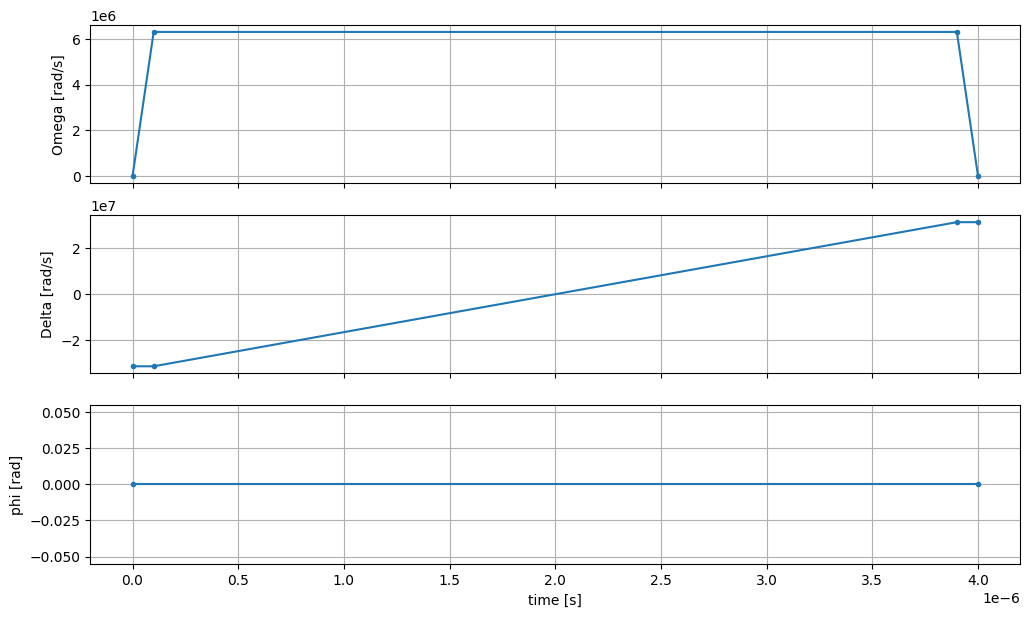

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
time_series = drive.amplitude.time_series
ax.plot(time_series.times(), time_series.values(), '.-');
ax.grid()
ax.set_ylabel('Omega [rad/s]')

ax = axes[1]
time_series = drive.detuning.time_series
ax.plot(time_series.times(), time_series.values(), '.-');
ax.grid()
ax.set_ylabel('Delta [rad/s]')

ax = axes[2]
time_series = drive.phase.time_series
# Note: time series of phase is understood as a piecewise constant function
ax.step(time_series.times(), time_series.values(), '.-', where='post');
ax.set_ylabel('phi [rad]')
ax.grid()
ax.set_xlabel('time [s]')

plt.show()  # this will show the plot below in an ipython or jupyter session